In this notebook I do a figure that explores:

$\braket{0|[A_l,P_n]|m}$ with $A_l =\sum \alpha_l O_l, O_l= \sum \sigma_x ... \sigma_y+\sigma_y...\sigma_x$

In [1]:
#Imports
import sys,os
os.environ['MKL_NUM_THREADS'] = '4' # set number of MKL threads to run in parallel
from quspin.operators import hamiltonian,quantum_operator
from quspin.basis import spin_basis_1d
from numpy.random import uniform,seed
from joblib import delayed,Parallel
from itertools import combinations
from functools import partial
import numpy as np
import gc
import pickle
from time import time
from quspin.tools.measurements import diag_ensemble
from quspin.tools.evolution import ED_state_vs_time
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot, show, figure, xlabel, ylabel, xscale, yscale, legend, loglog,title,show,imshow,colorbar,legend,scatter
from numpy import pi, exp, log, sin , cos, tan, log, array
import quspin
timestamp = time()
from scipy.optimize import minimize_scalar
# dat and alphasearch already defined
import warnings
warnings.filterwarnings("ignore")
# dat and alphasearch already defined
from tqdm import tqdm

In [117]:
###Functions
def timer(timestamp):
    #Timer Function
    print("time =", time()-timestamp)
    return

def fin_string(ns,s): #ns = length of string s = operator
    #Max string length
    if ns>L:
        ns=L
    else:
        pass
    
    
    def linears(start,m):
        #Find all indices in string
        ind=[i%L for i in range(start,start+ns)]
     #All combinations
        perm=list(combinations(ind,m))
      #Add each coupling to operator
        for j in range(len(perm)):
#            S_temp=[((-1)**m)*(2**m)/(L*(2**ns))] ########### Down #
            S_temp=[1/(1*(2**ns))] ###################### Up
            for i in range(len(perm[j])):
                S_temp.append(perm[j][i])
        ##Saving Couplin gs lists
            if j==0: 
                S_temp_2=[S_temp]
            else: 
                S_temp_2.append(S_temp)
        return S_temp_2
    #List to store orders of interaction
    o_type=np.empty(ns,dtype=object)
    
    for i in range(ns):
        #ex: "z"*2= "zz"
        o_type[i]=s*(i+1)

    #Iterate over each Site
    for k in range(1):
        #Iterate over different string lengths
      for i in range(ns):
          #First item defines list
          if k==0 and i==0:
              #example: i = 0 operator_list = [['x', linears(k,1)]]
              operator_list=[[o_type[i],linears(k,i+1)]]
          else:
              operator_list.append([o_type[i],linears(k,i+1)])
    S_temp_1 = [[(1/((ns*2**ns))), i] for i in range(ns)]
    #S_temp_1 = [[(1/((ns*2**(ns)))), 1] ]
    operator_list.append(["I",S_temp_1])
    operator_dict=dict(S=operator_list)
    O = quantum_operator(operator_dict,basis=basis,check_symm=False,check_herm=False)
    #print(operator_list)
    return array(O.todense())

def commute(A,B):
    return A@B-B@A
def diagonalize(op,basis):
    return basis.T@op@basis
def normalize(op):
    return np.abs(op)/np.max(np.abs(op))
def fnorm(op):
    return np.sum(np.abs(op)**2)
def O_l(l):
    if l ==0:
        return np.zeros(basis.Ns)
    str = "x"
    for l in range(1,l):
        str+= "z"
    str+="y"

    sites = [[1]+[(s+i)%L for i in range(len(str))] for s in range(L)]
    ops = [[str,sites], [str[::-1],sites]]
    op_dict = dict(S= ops)
    O = quantum_operator(op_dict,basis=basis,check_symm=False,check_herm=False)
    return array(O.todense())

def alpha_exact(l):
    k = 2*np.pi*(np.arange(L)+0.5)/L
    num = np.sin(k)*np.sin(l*k)
    den = (np.cos(k)-h0)**2 + np.sin(k)**2
    return -np.sum(num/den)/(4*L)

def alpha_M(l, M):
    k = np.pi*np.arange(1, M+1)/(M+1)
    num = np.sin(k)*np.sin(l*k)
    den = (np.cos(k)-h0)**2 + np.sin(k)**2
    return -np.sum(num/den)/(4*(M+1))


def A_e():
    A = [alpha_exact(l)*O_l(l) for l in np.arange(1,L)]
    return [sum(A[:i]) for i in range(1,len(A)+1)]
def A_m():
    Ms = np.arange(1,L)
    A_m =[sum([alpha_M(l,M)*O_l(l) for l in np.arange(1,M+1)]) for M in Ms]
    return A_m
    
L= 10
h0 = 1

basis = spin_basis_1d(L,pauli=-1)
print([fnorm(A) for A in A_e()])
print([fnorm(A) for A in A_m()])

[np.float64(320.0), np.float64(640.0), np.float64(959.9999999999999), np.float64(1279.9999999999998), np.float64(1599.9999999999998), np.float64(1919.9999999999998), np.float64(2240.0), np.float64(2559.9999999999995), np.float64(2879.9999999999995)]
[np.float64(80.00000000000001), np.float64(177.77777777777786), np.float64(280.00000000000006), np.float64(383.99999999999994), np.float64(488.8888888888887), np.float64(594.2857142857144), np.float64(699.9999999999999), np.float64(805.9259259259261), np.float64(912.0)]


In [118]:
#NN Sigma x term (Periodic Boundary Conditions)
NN_sigma_x = [ [-1, i, (i+1)%L] for i in range(L)]
sigma_z = [ [-1, i] for i in range(L)]
static_H = [ ["xx", NN_sigma_x]] 
Quenching_H = [["z", sigma_z]]
#Define operator dictionary
operator_dict = dict(H0= static_H, Quench = Quenching_H)
#Build Hamiltonian
H = quantum_operator(operator_dict, basis=basis, check_herm= False, check_symm = False)
#Define Parameters
params_dict = dict( H0=1, Quench=h0)
#Build H0
H = H.tohamiltonian(params_dict)
#Find eigenvalues
E,V = np.linalg.eigh(H.todense())
#Convert matrix to array
V = np.array(V)
H = array(H.todense())
E = E

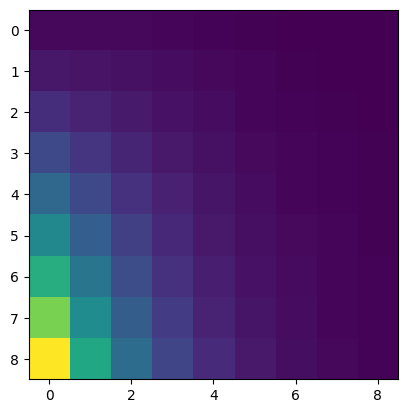

In [119]:
L = 10
basis = spin_basis_1d(L,pauli=-1)
ls = np.arange(1,L)
ns = np.arange(1,L)
As = A_e()
op = "x"
P = [fin_string(n,op) for n in ns]
dat = array([[fnorm(commute(p,a)) for p in P] for a in As])

imshow(dat)

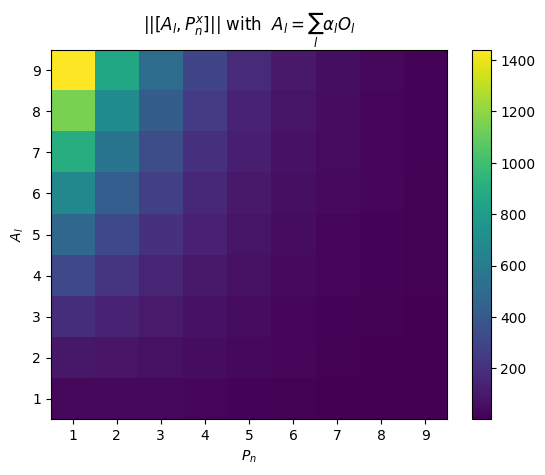

In [120]:
plt.imshow((dat), aspect="auto", origin="lower")
plt.xticks(ticks=np.arange(len(ns)), labels=ns)
plt.yticks(ticks=np.arange(len(ls)), labels=ls)
plt.xlabel(r"$P_n$")
plt.ylabel(r"$A_l$")
title(fr"$||[A_l,P^{op}_n]||$ with  $A_l = \sum_l \alpha_l O_l$")
plt.colorbar()
plt.savefig(f"figures/Al_P{op}_fnorm.png",dpi=500)

In [121]:
dat = [[diagonalize(commute(p,a),V) for p in P] for a in tqdm(As)]


100%|██████████| 9/9 [00:07<00:00,  1.18it/s]


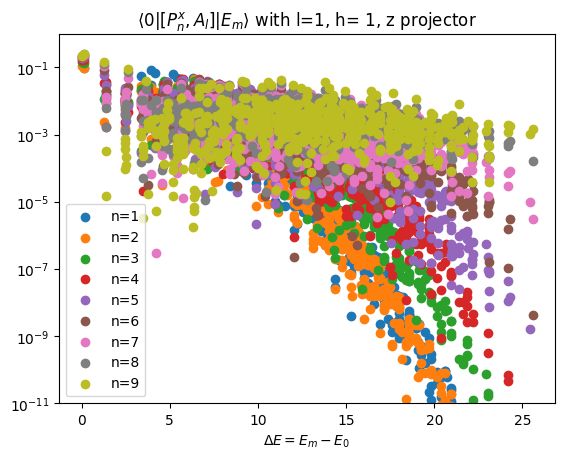

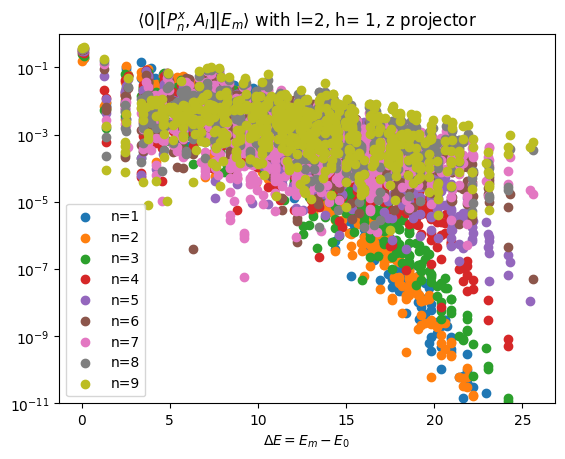

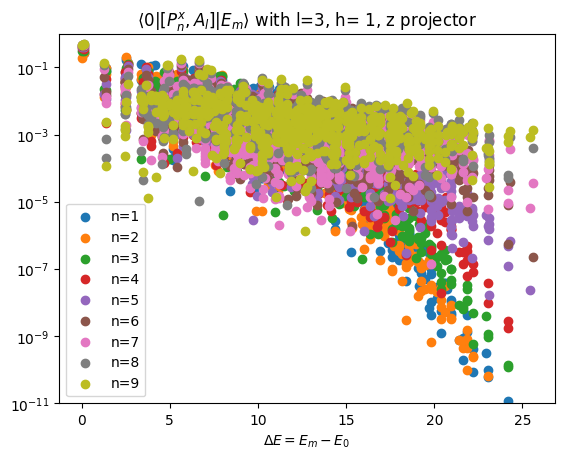

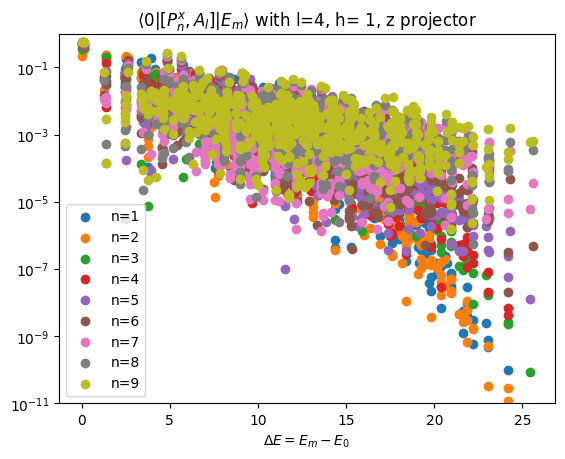

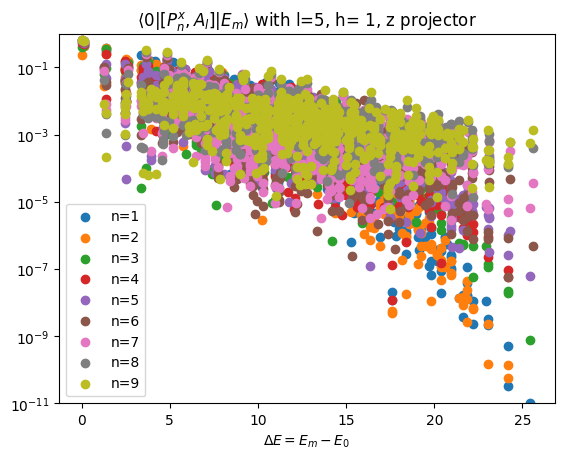

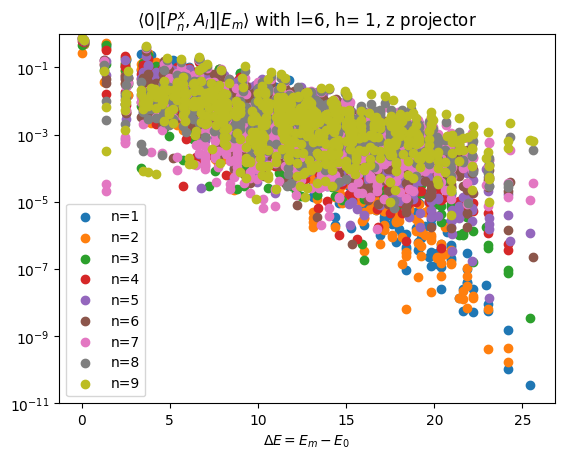

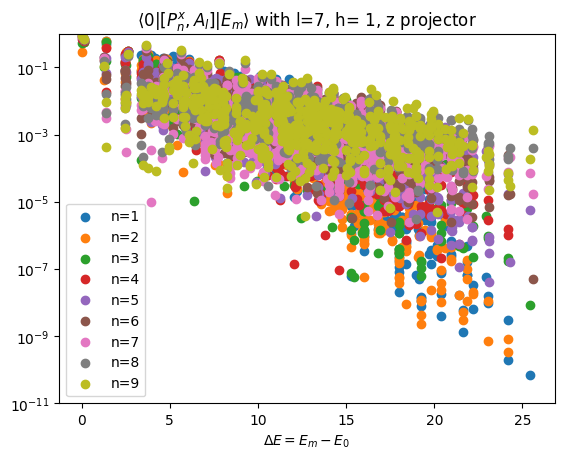

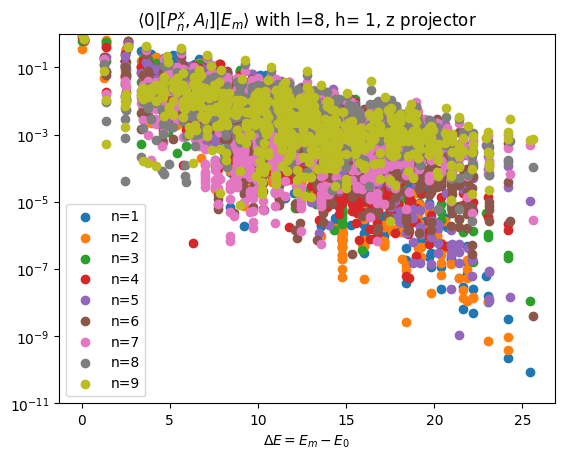

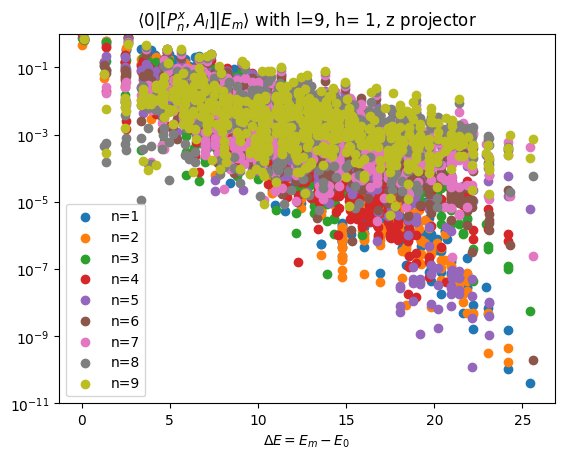

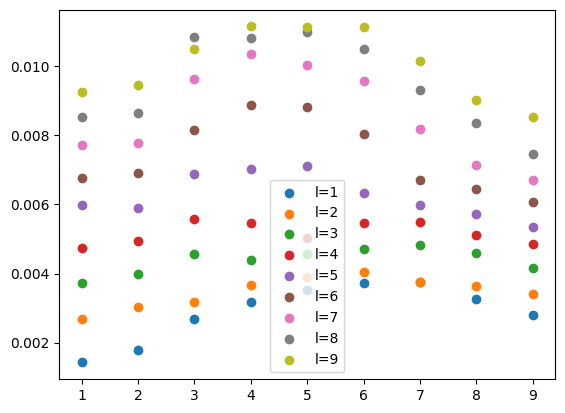

In [129]:
Fs=[]
for D,l in zip(dat,ls):
    F=[]
    for d,n in zip(D,ns):
        scatter(E-E[0],np.abs(d[0,:]),label=f"n={n}")
        F.append(np.average(np.abs(d[0,:])))
    legend()
    title(fr"$\langle 0| [P^{op}_n, A_l] | E_m \rangle$ with " + f"l={l}, h= {h0}, z projector")
    yscale("log")
    plt.ylim(10e-12,1)
    plt.xlabel(r"$\Delta E = E_m-E_0$")
    #plt.savefig(f"figures/Ol_Pz/Al_P{op}_fixed_l={l}.png",dpi=500)
    show()
    Fs.append(F)

for f,l in zip(Fs,ls):
    scatter(ns,f,label=f"l={l}")
legend()

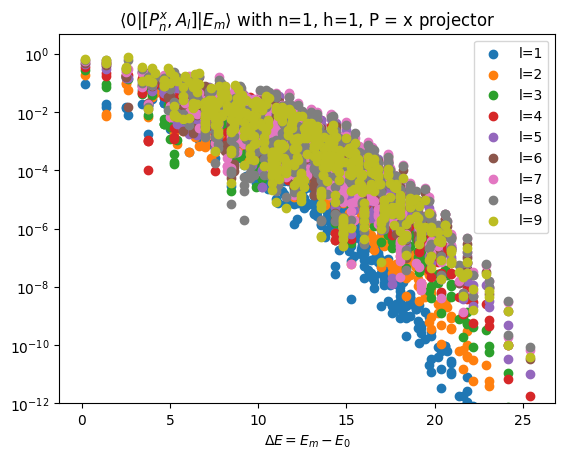

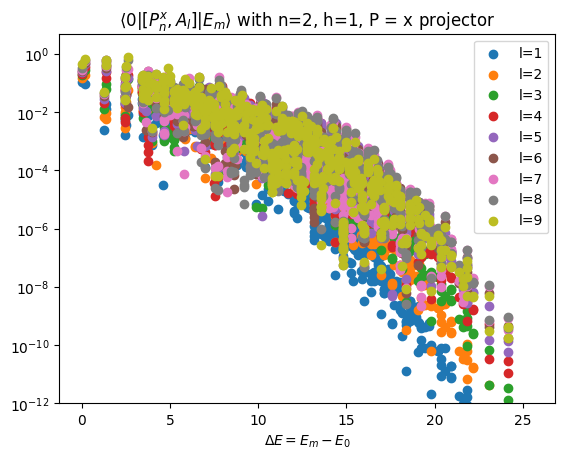

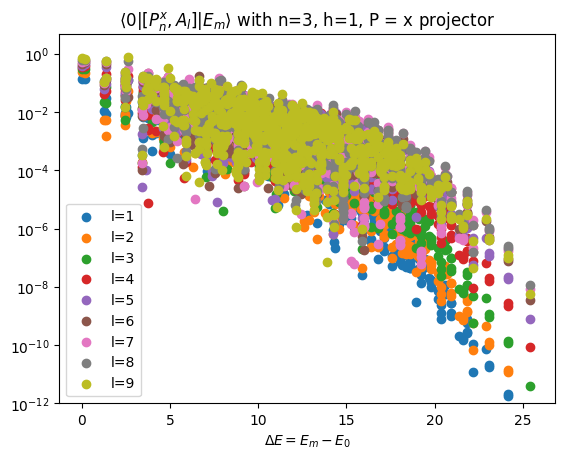

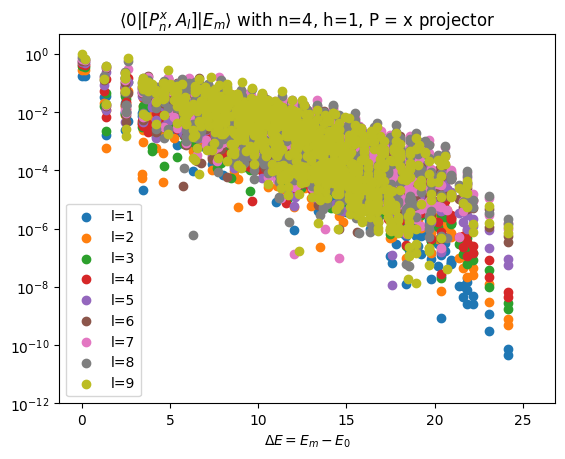

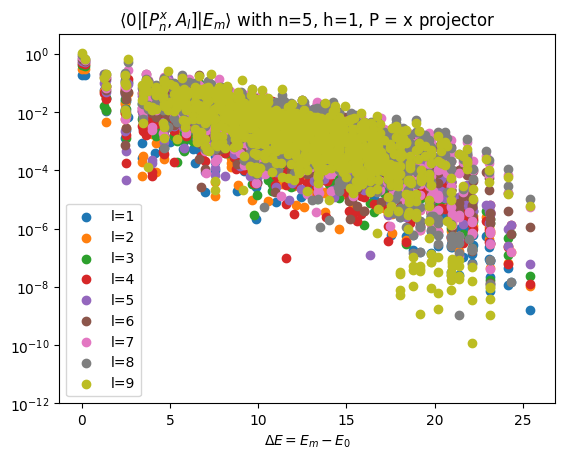

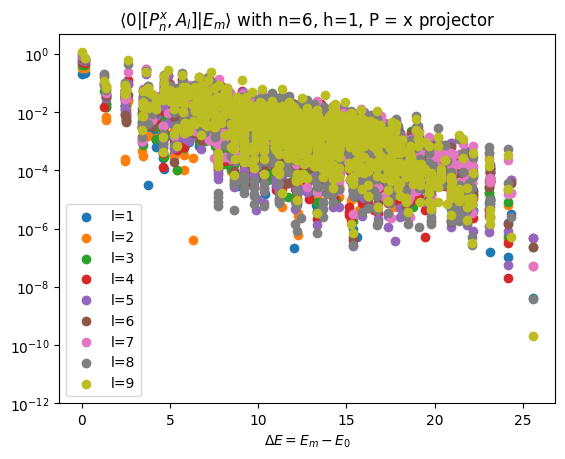

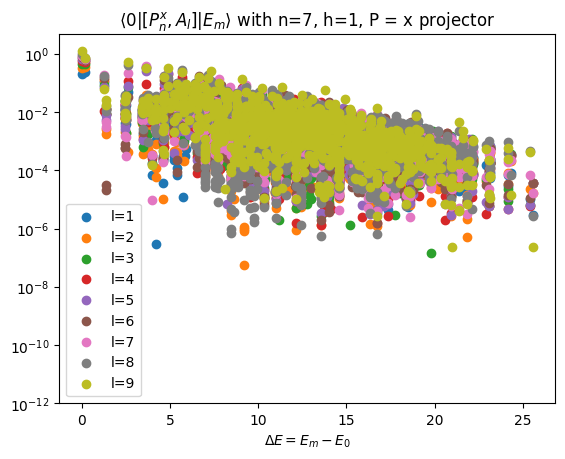

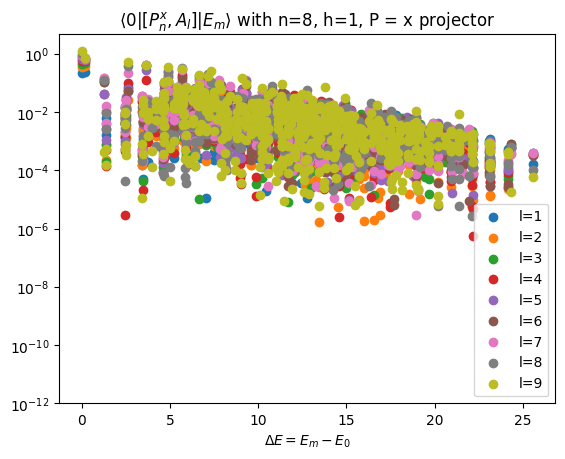

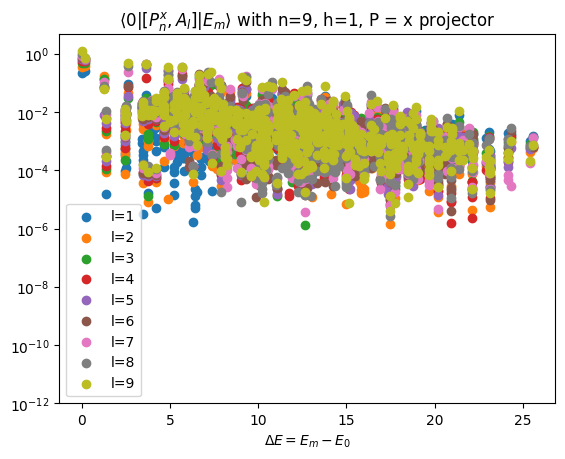

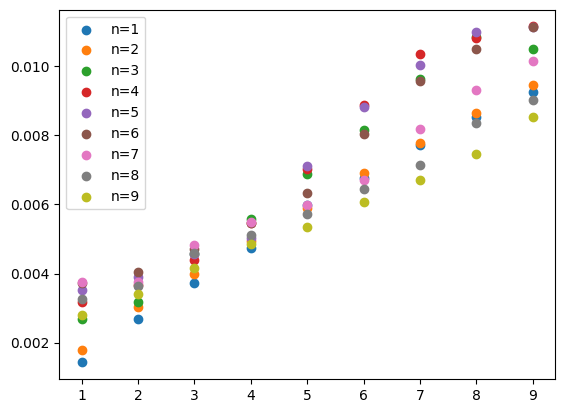

In [133]:
Fs=[]
for n_idx, n in enumerate(ns):
    F=[]
    for D, l in zip(dat, ls):
        d = D[n_idx]                      # commutator for this n and l
        scatter(E - E[0], np.abs(d[0, :]), label=f"l={l}")
        F.append(np.average(np.abs(d[0,:])))

    legend()
    title(fr"$\langle 0| [P^{op}_n, A_l] | E_m \rangle$ with " + f"n={n}, h={h0}, P = x projector")
    yscale("log")
    plt.ylim(1e-12, 5)
    
    plt.xlabel(r"$\Delta E = E_m - E_0$")
    plt.savefig(f"figures/Ol_Pz/Al_P{op}_fixed_n={n}.png",dpi=500)

    show()
    Fs.append(F)

for f,n in zip(Fs,ns):
    scatter(ls,f,label=f"n={n}")
legend()
